In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [ ]:
file = pd.read_csv('../datasets/process_pima.csv')
train = file.copy()
train.head()
train.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.598177,72.371354,29.114583,153.180208,32.427344,0.471876,33.240885,0.348958
std,3.369578,30.496543,12.206417,9.424100,98.385308,6.886588,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,23.000000,87.900000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,133.700000,32.090000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,35.000000,190.150000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


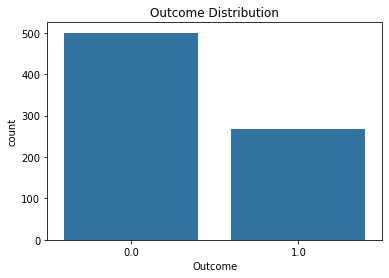

In [11]:
# check the distribution of each variable and its relationship with the label
sns.countplot(x='Outcome',data=train)
plt.title('Outcome Distribution')
plt.show()

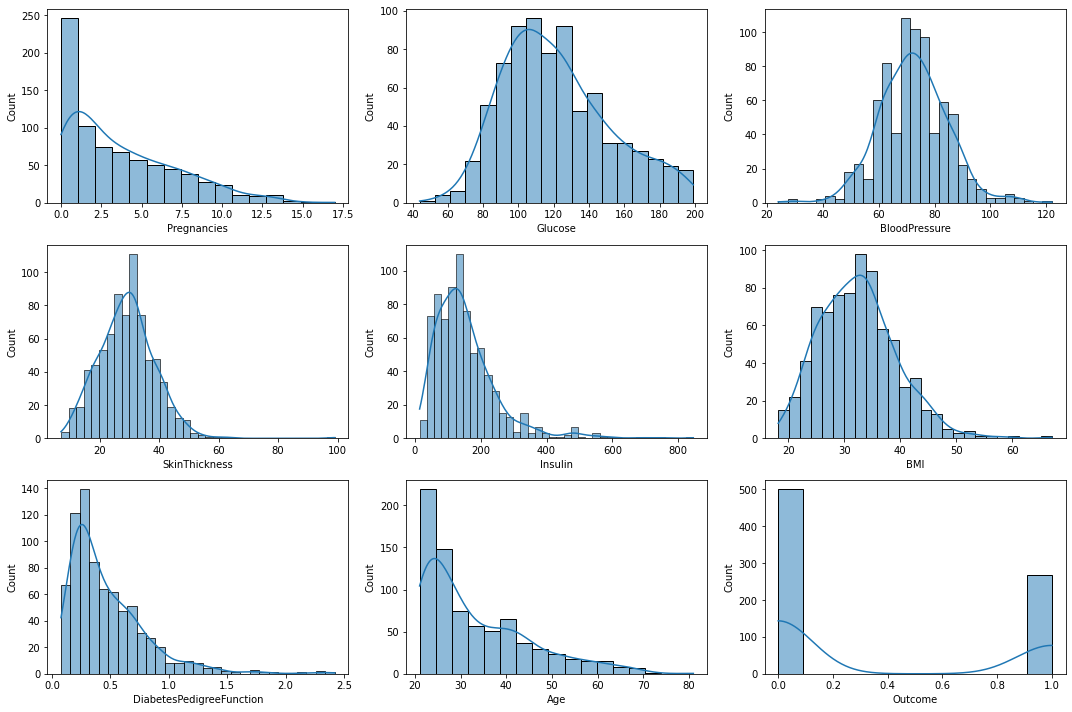

In [12]:
# the distribution of each variable
fig, axes = plt.subplots(3,3,figsize=(15,10))
for i,col in enumerate(train.columns):
    sns.histplot(train[col],kde=True,ax=axes[i//3,i%3])
plt.tight_layout()
plt.show()

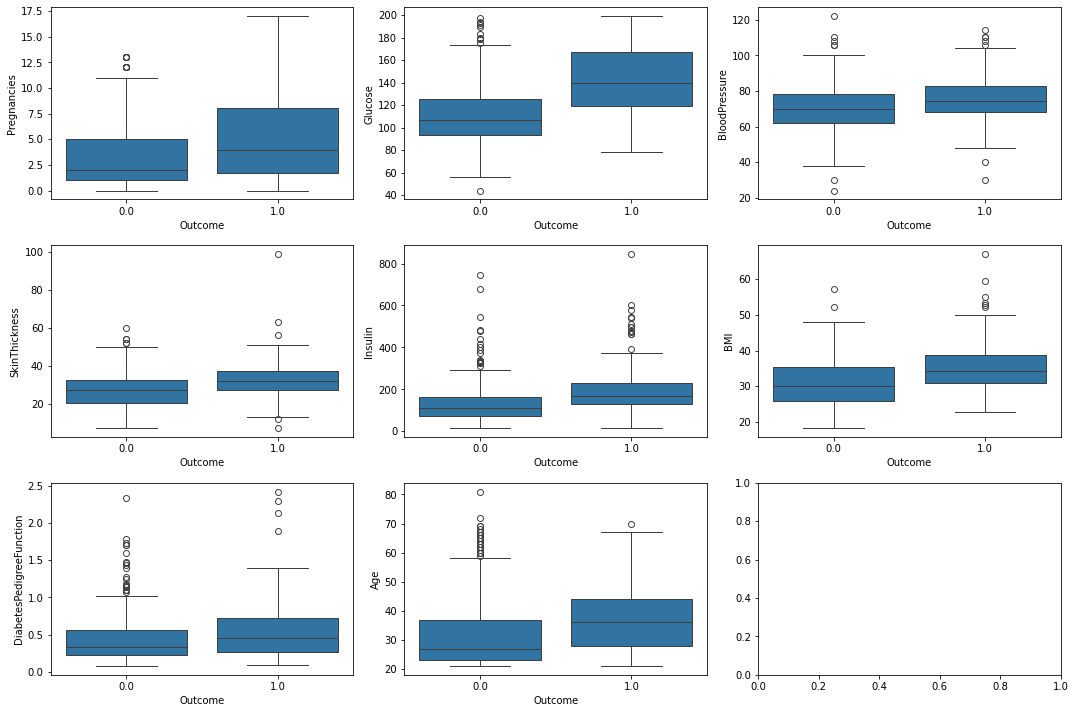

In [13]:
# the relationship between each variable and the label
fig, axes = plt.subplots(3,3,figsize=(15,10))
for i,col in enumerate(train.columns[:-1]):
    sns.boxplot(x='Outcome',y=col,data=train,ax=axes[i//3,i%3])
plt.tight_layout()
plt.show()

# from the below correlation boxplot, we can see that the 'Pregnancies', 'Glucose', 'BMI' and 'Age' have a strong correlation with the label 'Outcome' compared to the other variables.

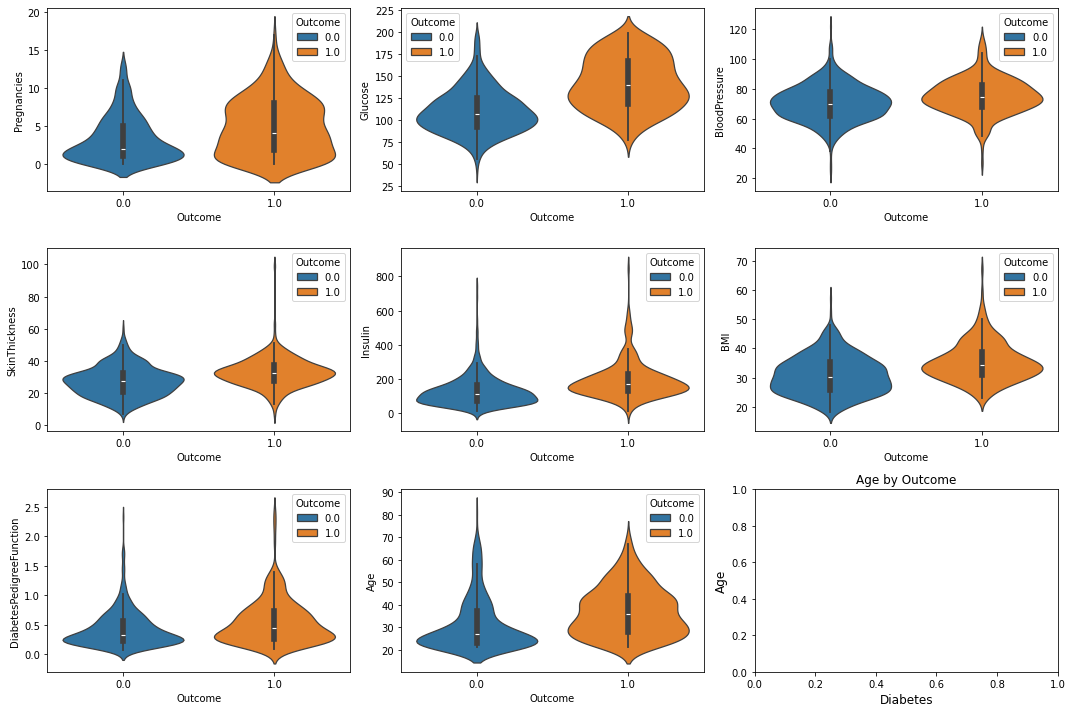

In [14]:
# use a violin plot to show the distribution of each variable with respect to the label 
fig, axes = plt.subplots(3,3,figsize=(15,10))

for i,col in enumerate(train.columns[:-1]):
    if col == 'Outcome':
        continue
    sns.violinplot(x='Outcome',y=col,data=train,ax=axes[i//3,i%3],hue='Outcome')
    plt.xlabel('Diabetes', fontsize=12)
    plt.ylabel(col, fontsize=12)
    plt.title(f'{col} by Outcome')
plt.tight_layout()
plt.show()
# from the below violin plot, we can see that the 'SkinThickness' have a strong correlation with the label 'Outcome' compared to the other variables.


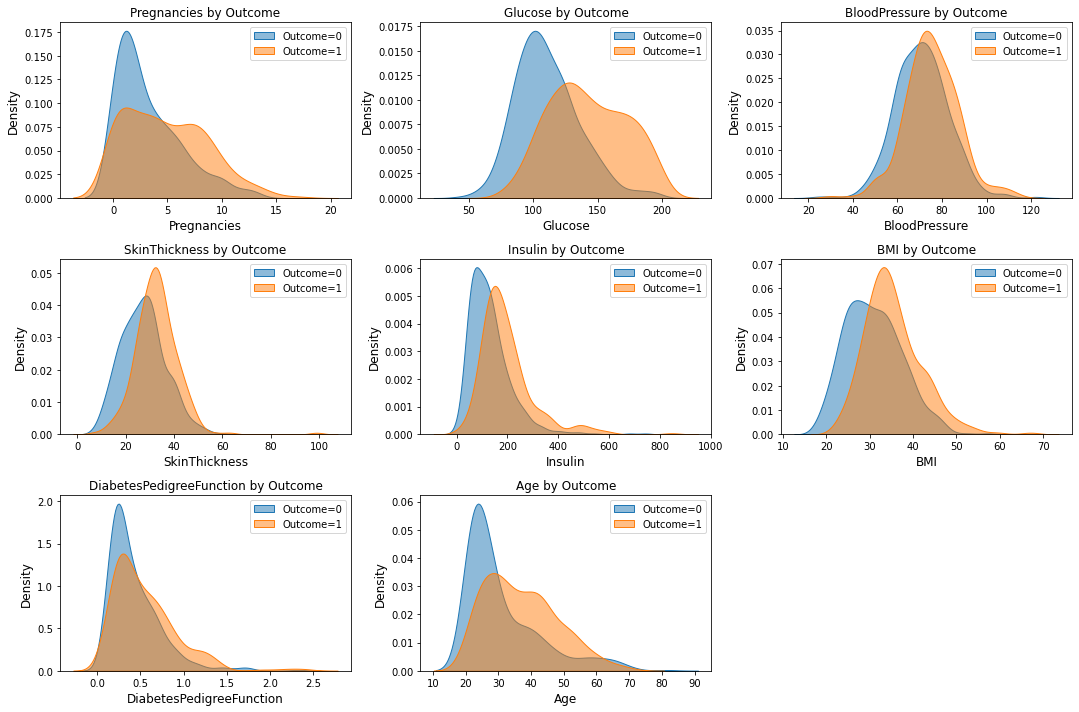

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()  

plot_idx = 0
for i, col in enumerate(train.columns[:-1]):  
    if col == 'Outcome':
        continue
    
    ax = axes[plot_idx]
    
    for outcome in [0, 1]:
        subset = train[train['Outcome'] == outcome][col]
        sns.kdeplot(data=subset, label=f'Outcome={outcome}', ax=ax, fill=True, alpha=0.5)
    
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'{col} by Outcome')
    ax.legend()
    
    plot_idx += 1

for j in range(plot_idx, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

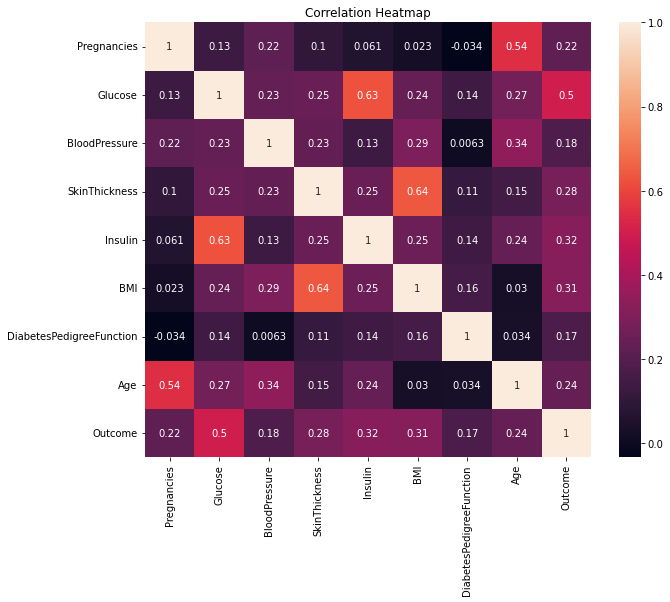

In [15]:
data_corr = train.corr()
plt.figure(figsize=(10,8))
sns.heatmap(data_corr, annot=True)
plt.title('Correlation Heatmap')
plt.show()